# End-to-End Spectral Analysis with pySpectrum

This notebook walks through the complete pySpectrum analysis pipeline on a ¹⁵²Eu gamma-ray spectrum:

1. Load and energy-calibrate the raw spectrum
2. Estimate and subtract a global SNIP background
3. Identify peak domains via SNR convolution
4. Estimate the local domain background (erf and linear models)
5. Fit overlapping peaks with `MultiGaussianFitter(background='erf')`

Each step feeds naturally into the next — the same `Spectrum`, `Domain`, and `MultiGaussianFitter` objects are reused throughout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scispectrum.core import Spectrum, Domain
from scispectrum.calibration.detector_calibration import DetectorCalibration, StandardHPGeFWHMModel, PolynomialEnergyModel
from scispectrum.background.snip import SNIPBackground
from scispectrum.domain_analysis.background import domain_erf_background, domain_linear_background
from scispectrum.domain_analysis.morphology import domain_peaks_position, find_domain_peaks

## 1. Load and calibrate

> **Adapt:** replace `path`, `domains`, and `energies` with values for your own source and detector. The calibration workflow is detailed in the *Calibration* notebook.

In [2]:
# ── Adapt to your source and detector ────────────────────────────────────────
path     = '../Library/152Eu_calsource_10cm_85ks.txt'
domains  = [(300,320),(1057,1082),(2544,2567),(3177,3202),(3597,3612),(3687,3707),(4687,4727)]
energies = [121.78, 344.28, 778.9, 964.08, 1085.837, 1112.076, 1408.0]   # keV
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(path, names=['counts'])
first_non_zero = np.where(df['counts'] > 0)[0][0]
df = df[first_non_zero:].reset_index(drop=True)
df['channel'] = df.index

spectrum = Spectrum.from_dataframe(df=df, channel_col='channel', counts_col='counts')

detector_calibration = DetectorCalibration(
    spectrum, known_axis_values=energies, peak_domains=domains,
    energy_model=PolynomialEnergyModel(2), fwhm_model=StandardHPGeFWHMModel(),
)
energy_calib, fwhm_calib = detector_calibration.generate(energy_p0=(0,1,0), fwhm_p0=(0,1,0))
spectrum.set_axis_calibration(energy_calib)
spectrum.set_resolution_calibration(fwhm_calib)

In [3]:
spectrum

<xarray.DataArray (energy: 8109)> Size: 65kB
array([19919, 25115, 26717, ...,     3,     4,     3], shape=(8109,))
Coordinates:
  * energy   (energy) float64 65kB 30.98 31.27 31.56 ... 2.401e+03 2.401e+03

Text(0, 0.5, 'Counts')

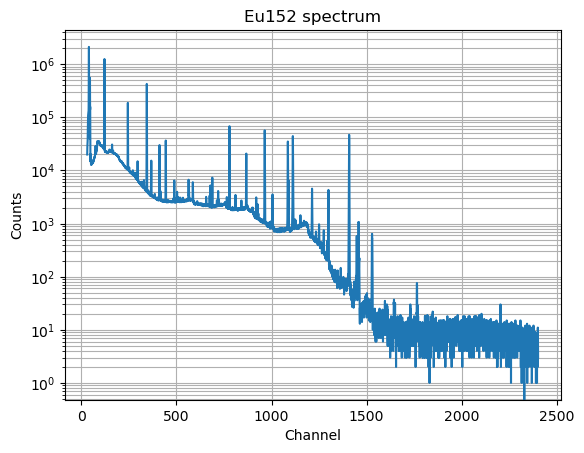

In [4]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Channel')
plt.ylabel('Counts')

## 2. Global SNIP background

The SNIP algorithm estimates the full-spectrum Compton continuum. Subtracting it reveals the net photopeaks for subsequent domain analysis.

> **Adapt `iterations`:** more iterations → tighter continuum estimate. Typical: 10–40.

choose the obvious photobpeaks in the spectrum

uncomment here if you wat to see the what are the dominenent peaks in the spectrum

In [5]:
#import curie
#Eu152 =  curie.Isotope('EU-152')
#gamma_df = Eu152.gammas()
#gamma_df[gamma_df['intensity']>5]
#
#gamma_df = Eu152.gammas()
#gamma_df[gamma_df['intensity']>5]

In [6]:
#domains = [(383, 403), (1140,1165), (2627, 2650), (3260,3285), (3680, 3695), (3770,3790), (4770, 4810)]
# the domain after adding the first_non_zero
domains = [(300,320),(1057,1082),(2544,2567),(3177,3202),(3597,3612),(3687,3707),(4687,4727)]
energies = [121.78, 344.28, 778.9, 964.08, 1085.8370, 1112.0760, 1408]
detector_calibration = DetectorCalibration(spectrum,
                                           known_axis_values=energies, peak_domains=domains,
                                          energy_model=PolynomialEnergyModel(2), fwhm_model=StandardHPGeFWHMModel())

In [7]:
energy_calib, fwhm_calib = detector_calibration.generate(energy_p0=(0,1,0), fwhm_p0=(0,1,0))

In [8]:
spectrum.set_axis_calibration(energy_calib)
spectrum.set_resolution_calibration(fwhm_calib)

Text(0, 0.5, 'Counts')

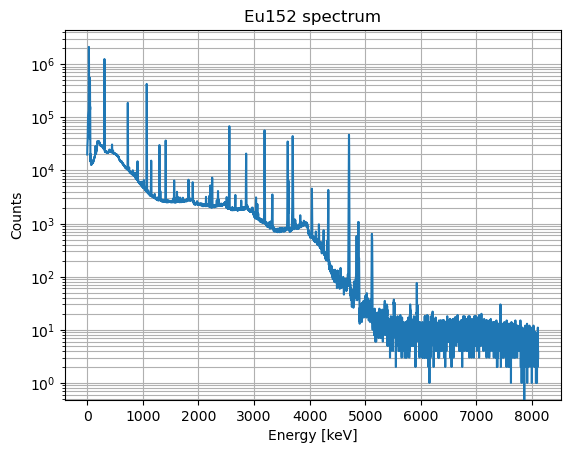

In [9]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')

find the calibration

In [10]:
detector_calibration = DetectorCalibration(spectrum,
                                           known_axis_values=energies, peak_domains=domains,
                                          energy_model=PolynomialEnergyModel(2), fwhm_model=StandardHPGeFWHMModel())
peaks_center_ch, fwhm_val = detector_calibration.estimate_peaks()

In [11]:
fwhm_energy_val = [spectrum.axis[int(ch_center+fwhm_val[i])]-spectrum.axis[int(ch_center)] for i, ch_center in enumerate(np.round(peaks_center_ch))]

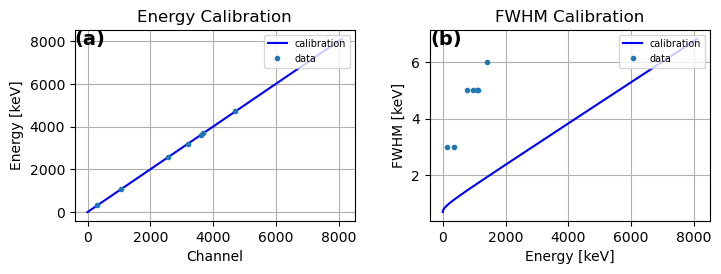

In [12]:
# === Create Side-by-Side Figure ===
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(7.1, 2.625), constrained_layout=True, gridspec_kw={'wspace': 0.1} )

# === Left plot: Energy Calibration ===
ax1.plot(spectrum.channels, spectrum.axis_calib.apply(spectrum.channels), 'b-', label='calibration')
ax1.plot(peaks_center_ch, spectrum.axis_calib.apply(peaks_center_ch), marker='.', ls='', label='data')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Energy [keV]')
ax1.set_title('Energy Calibration')
ax1.grid(which='both')
ax1.legend(fontsize='x-small', loc='upper right', frameon=True)
ax1.text(0, 1, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')

# === Right plot: FWHM  ===
ax2.plot(spectrum.axis_calib.apply(spectrum.channels), spectrum.resolution_calib.apply(spectrum.axis_calib.apply(spectrum.channels)), 'b-', label='calibration')
ax2.plot(energies, fwhm_energy_val, marker='.', ls='', label='data')
ax2.set_xlabel('Energy [keV]')
ax2.set_ylabel('FWHM [keV]')
ax2.set_title('FWHM Calibration')
ax2.grid(which='both')
ax2.legend(fontsize='x-small', loc='upper right', frameon=True)
ax2.text(0, 1.0, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')

# === Show ===
plt.show()


# Operations

Note that the spectrum object can be treated as an xarray (mostly)\
This means it can be normlized and operated easly

Text(0, 0.5, 'Counts rate [cps]')

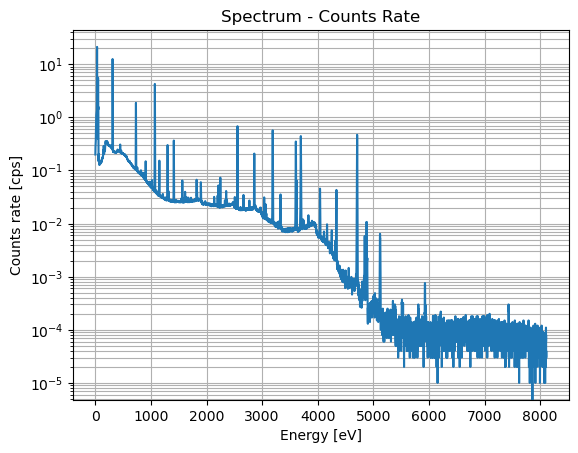

In [13]:
measurement_time = 1e5
(spectrum/measurement_time).plot(yscale='log')
plt.grid(True, which='both')
plt.title('Spectrum - Counts Rate')
plt.xlabel('Energy [eV]')
plt.ylabel('Counts rate [cps]')

## findPeaks
An example how to find domains in which the counts are above snr

In [14]:
from scispectrum.identification import Convolution
from scispectrum.identification.snr import SNRFinder
from scispectrum.identification.kernels.mexican_hat import gaussian_2_dev

In [15]:
# ── Adapt detection thresholds ────────────────────────────────────────────────
n_sigma_signal     = 5.0
n_sigma_background = 2.5
persistence        = 1.0
# ─────────────────────────────────────────────────────────────────────────────

conv   = Convolution(resolution=spectrum.resolution_calib.apply,
                     kernel=gaussian_2_dev, window_fwhm=4)
finder = SNRFinder(convolution=conv,
                   n_sigma_signal_threshold=n_sigma_signal,
                   n_sigma_bg_threshold=n_sigma_background,
                   persistence_factor=persistence)
found_domains = finder.find(spectrum)
print(f"Detected {len(found_domains)} peak domains")

Detected 47 peak domains


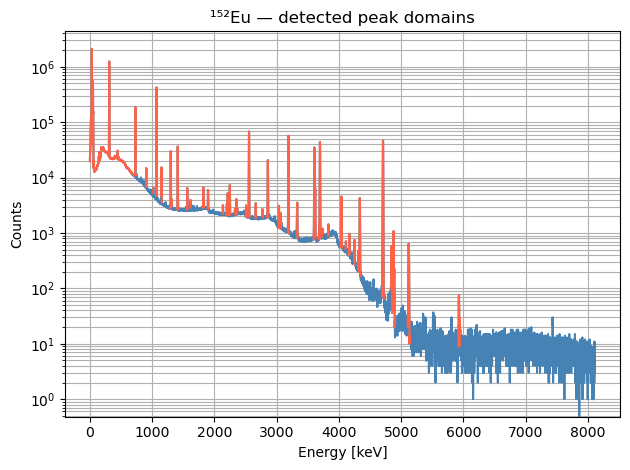

In [17]:
spectrum.data.plot(yscale='log', color='steelblue')
for domain in found_domains:
    try:
        domain.data.plot(color='tomato')
    except:
        pass

plt.title('¹⁵²Eu — detected peak domains')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

## 4. Local domain background estimation

For a specific peak region, `domain_erf_background` fits a prominence-weighted erf step that models the Compton edge beneath the peaks. `domain_linear_background` is a simpler linear interpolation between the domain edges — useful as a quick check or for narrow regions.

The complex low-energy region (8–65 keV) is chosen here because it contains multiple overlapping lines and a significant background slope.

In [18]:
# global bg

In [19]:
snip_bg = SNIPBackground(iterations=15, resolution=spectrum.resolution_calib, smooth=True)
bg_estimation = snip_bg.estimate(spectrum.axis, spectrum.counts)
subtracted_spectrum = spectrum - bg_estimation

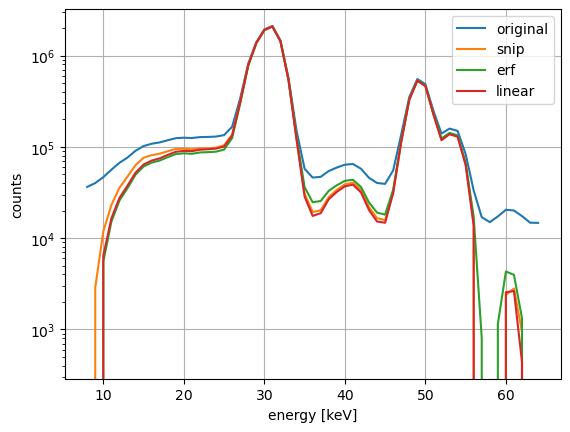

In [20]:
complex_domain = Domain(spectrum, start=8, stop=65)
complex_domain_subtracted = Domain(subtracted_spectrum, start=8, stop=65)

complex_domain.data.plot(yscale='log', label='original')
complex_domain_subtracted.data.plot(yscale='log', label='snip')

erf_bg = domain_erf_background(complex_domain)
lin_bg = domain_linear_background(complex_domain)

complex_domain.subtract_background(erf_bg).data.plot(yscale='log', label='erf')
complex_domain.subtract_background(lin_bg).data.plot(yscale='log', label='linear')

plt.xlabel("energy [keV]")
plt.ylabel("counts")
plt.legend()
plt.grid()

## 5. Peak fitting with erf background

`MultiGaussianFitter(background='erf')` fits the Gaussian peaks and the erf step continuum simultaneously — no prior background subtraction is needed. The erf background parameters (`height_diff`, `peak_baseline`) are included in the covariance matrix, so their uncertainty is propagated into the peak parameters.

> **Adapt `minimal_prominence`** to control which peaks are included in the initial guess. Here it is derived from the Mariscotti criterion for a given statistical accuracy.

(8.000012968715971, 65.0000099689289)

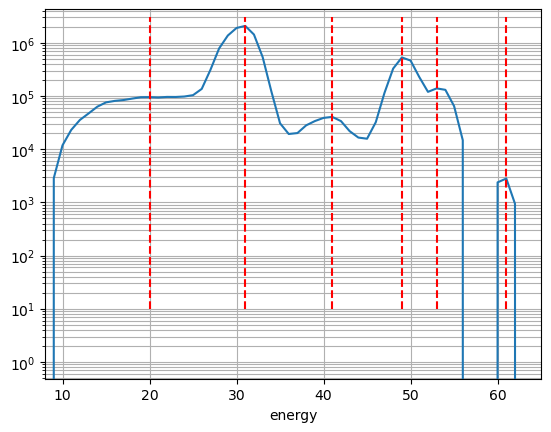

In [21]:
minimal_statistical_accuracy = 0.05
resolution = spectrum.resolution_calib.apply(25) / (2 * np.sqrt(2 * np.log(2)))
minimal_counts_in_peak = 1 / minimal_statistical_accuracy ** 2
minimal_prominence = minimal_counts_in_peak / (0.761438079 * np.sqrt(2 * np.pi) * resolution)

complex_domain_subtracted.data.plot(yscale='log')

for c in domain_peaks_position(complex_domain_subtracted, smooth=True, prominence=minimal_prominence):
    plt.vlines(ymax=3e6, ymin=10, x=c, color='red', ls='--')
plt.grid(True, which='both')
plt.xlim([spectrum.axis[complex_domain.start], spectrum.axis[complex_domain.stop]])

In [22]:
domain_peak_positions, domain_peak_propeties = find_domain_peaks(complex_domain, smooth=True, prominence=minimal_prominence)
domain_peak_positions

array([20.00001232, 31.00001173, 41.0000112 , 49.00001079, 53.00001058,
       60.00001022])

In [23]:
from scispectrum.domain_fitting import MultiGaussianFitter

fitter_erf = MultiGaussianFitter(background='erf')

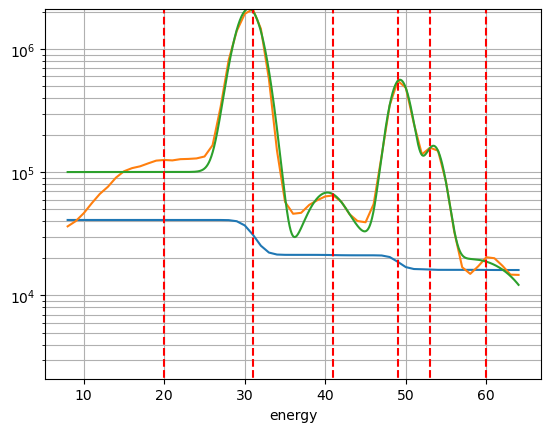

In [24]:
fitting_evaluation_axis = np.linspace(complex_domain.axis[0], complex_domain.axis[-1], num=int(1e5))
parms = fitter_erf.fit(complex_domain, prominence=minimal_prominence)
val = fitter_erf.evaluate(fitting_evaluation_axis, parms)

plt.plot(complex_domain.axis, erf_bg)
complex_domain.data.plot(yscale='log')
plt.plot(fitting_evaluation_axis, val)

for c in domain_peaks_position(complex_domain, smooth=True, prominence=minimal_prominence):
    plt.vlines(ymax=3e6, ymin=10, x=c, color='red', ls='--')
plt.grid(True, which='both')
plt.ylim([complex_domain.max() * 1e-3, complex_domain.max()])
plt.yscale('log')

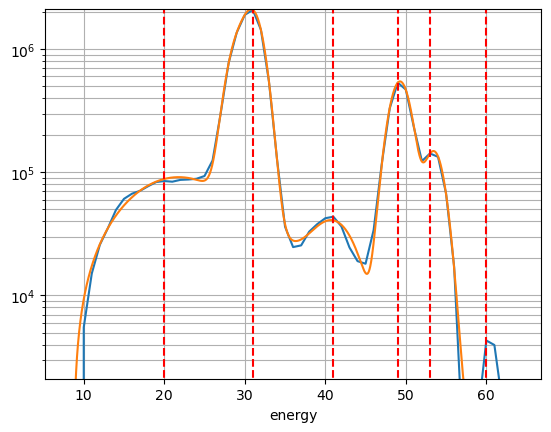

In [25]:
complex_domain_erf = complex_domain.subtract_background(erf_bg)

fitting_evaluation_axis = np.linspace(complex_domain.axis[0], complex_domain.axis[-1], num=int(1e5))
parms = fitter_erf.fit(complex_domain_erf, prominence=minimal_prominence, maxiter=1000)
val = fitter_erf.evaluate(fitting_evaluation_axis, parms)

complex_domain_erf.data.plot(yscale='log')
plt.plot(fitting_evaluation_axis, val)

for c in domain_peaks_position(complex_domain, smooth=True, prominence=minimal_prominence):
    plt.vlines(ymax=3e6, ymin=10, x=c, color='red', ls='--')
plt.grid(True, which='both')
plt.ylim([complex_domain.max() * 1e-3, complex_domain.max()])
plt.yscale('log')